# Предсказание покупки в течение 90 дней

**Задача.** Интернет-магазин одежды хочет заранее выделять клиентов, готовых совершить
покупку в ближайшие 90 дней, чтобы точнее таргетировать рассылки. Нужно построить модель
бинарной классификации и максимизировать **ROC-AUC**.

**Данные.**
- `apparel-purchases` — история покупок (клиент, товар, цена, количество, категории, дата);
- `apparel-messages` — история рассылок (событие: send/open/click/purchase/…, канал, дата);
- `apparel-target_binary` — целевая метка: совершит ли клиент покупку в следующие 90 дней;
- `full_campaign_daily_event(_channel)` — агрегированная по дням статистика кампаний.

**План.** EDA → определение временной границы → признаки (RFM по покупкам, категории,
поведение в рассылках) → базовые модели и кросс-валидация → тюнинг → финальная оценка на
отложенной выборке → проверка на утечку.

## 1. Импорты и конфигурация

In [1]:
import ast
import warnings
import numpy as np
import pandas as pd
from scipy.stats import rankdata

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

# >>> при необходимости поправьте путь к данным <<<
DATA_DIR = "/Users/sandyclawz/Desktop/Обучение/Data Science/Projects/marketplace/filtered_data"

## 2. Загрузка и первичный обзор

Таблицы покупок и таргета небольшие, читаем целиком. Файл рассылок большой (~1.4 ГБ),
поэтому его будем обрабатывать чанками на этапе построения признаков.

In [2]:
purchases = pd.read_csv(f"{DATA_DIR}/apparel-purchases.csv",
                        dtype={"client_id": str}, parse_dates=["date"])
target = pd.read_csv(f"{DATA_DIR}/apparel-target_binary.csv", dtype={"client_id": str})

print("purchases:", purchases.shape)
print("target:   ", target.shape)
purchases.head()

purchases: (202208, 6)
target:    (49849, 2)


,client_id,quantity,price,category_ids,date,message_id
0,1515915625468169594,1,1999.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
1,1515915625468169594,1,2499.0,"['4', '28', '57', '431']",2022-05-16,1515915625468169594-4301-627b661e9736d
2,1515915625471138230,1,6499.0,"['4', '28', '57', '431']",2022-05-16,1515915625471138230-4437-6282242f27843
3,1515915625471138230,1,4999.0,"['4', '28', '244', '432']",2022-05-16,1515915625471138230-4437-6282242f27843
4,1515915625471138230,1,4999.0,"['4', '28', '49', '413']",2022-05-16,1515915625471138230-4437-6282242f27843


In [3]:
print("Период покупок:", purchases['date'].min().date(), "->", purchases['date'].max().date())
print("Уникальных клиентов в покупках:", purchases['client_id'].nunique())
print("Уникальных клиентов в таргете: ", target['client_id'].nunique())
print("\nБаланс классов:")
print(target['target'].value_counts(normalize=True).round(4))

Период покупок: 2022-05-16 -> 2024-02-16
Уникальных клиентов в покупках: 49849
Уникальных клиентов в таргете:  49849

Баланс классов:
target
0    0.9807
1    0.0193
Name: proportion, dtype: float64


Классы сильно несбалансированы: доля положительного класса ≈ **1.9%**. Все клиенты из таргета
присутствуют в истории покупок, то есть это «действующие» покупатели, и мы предсказываем их
повторную покупку. Несбалансированность учтём через `class_weight="balanced"` и метрику ROC-AUC
(она устойчива к дисбалансу).

## 3. Временная граница и защита от утечки

Ключевой момент любой задачи с временны́м таргетом — не использовать информацию из будущего.

История покупок и рассылок заканчивается на **2024-02-16**. Целевое окно (следующие 90 дней)
в предоставленные таблицы **не входит** — это отдельно посчитанная метка. Поэтому за точку
среза (snapshot) берём последнюю доступную дату, и все признаки считаем строго по данным
до неё. Утечки не возникает, так как события целевого окна физически отсутствуют в данных.

In [4]:
SNAPSHOT = pd.Timestamp("2024-02-16")
print("Snapshot (точка среза):", SNAPSHOT.date())

Snapshot (точка среза): 2024-02-16


## 4. Признаки по покупкам (RFM и производные)

Считаем классические RFM-показатели и их расширения: давность последней покупки (recency),
частоту (frequency), сумму (monetary), активность в скользящих окнах 30/90/180/365 дней,
средний интервал между покупками и признак тренда (покупки в последние 90 дней против
предыдущих 90).

In [5]:
def build_purchase_features(pur, snapshot):
    pur = pur.copy()
    pur["amount"] = pur["price"] * pur["quantity"]

    g = pur.groupby("client_id")
    f = pd.DataFrame(index=g.size().index)
    f["p_n_tx"] = g.size()                       # число строк-транзакций
    f["p_n_days"] = g["date"].nunique()          # число дней с покупками
    f["p_total_qty"] = g["quantity"].sum()
    f["p_total_spend"] = g["amount"].sum()
    f["p_avg_price"] = g["price"].mean()
    f["p_max_price"] = g["price"].max()
    f["p_min_price"] = g["price"].min()
    f["p_avg_amount"] = g["amount"].mean()

    last, first = g["date"].max(), g["date"].min()
    f["p_recency_days"] = (snapshot - last).dt.days
    f["p_tenure_days"] = (snapshot - first).dt.days
    f["p_span_days"] = (last - first).dt.days
    f["p_avg_interpurchase"] = f["p_span_days"] / (f["p_n_days"] - 1).replace(0, np.nan)

    for w in (30, 90, 180, 365):
        sub = pur[pur["date"] > snapshot - pd.Timedelta(days=w)]
        f[f"p_tx_last_{w}"] = sub.groupby("client_id").size()
        f[f"p_spend_last_{w}"] = sub.groupby("client_id")["amount"].sum()

    prev = pur[(pur["date"] <= snapshot - pd.Timedelta(days=90)) &
               (pur["date"] > snapshot - pd.Timedelta(days=180))]
    f["p_tx_prev_90"] = prev.groupby("client_id").size()

    f = f.fillna(0)
    f["p_repeat_buyer"] = (f["p_n_days"] > 1).astype(int)
    return f

### Обработка вложенных `category_ids`

Список категорий может менять глубину вложенности при обновлении дерева, а нумерация сквозная
для всех уровней. Чтобы признаки были устойчивы к таким изменениям, **не опираемся на позицию**
в списке: считаем присутствие id (число различных категорий у клиента) и число покупок по
топ-уровневым категориям (по частоте первого элемента списка — `4, 5562, 2, 6060, 5963`).
Мелкие id в начале списка (маркеры распродажи/пол) при таком подходе не мешают.

In [6]:
TOP_CATEGORIES = ["4", "5562", "2", "6060", "5963"]

def parse_cat(s):
    try:
        v = ast.literal_eval(s)
        return v if isinstance(v, list) else []
    except Exception:
        return []

def build_category_features(pur):
    pur = pur.copy()
    pur["cats"] = pur["category_ids"].apply(parse_cat)
    f = pd.DataFrame(index=pur["client_id"].unique())
    f.index.name = "client_id"

    exploded = pur[["client_id", "cats"]].explode("cats")
    f["p_n_distinct_cat"] = exploded.groupby("client_id")["cats"].nunique()

    pur["top"] = pur["cats"].apply(lambda l: l[0] if l else None)
    for c in TOP_CATEGORIES:
        f[f"p_cat_{c}"] = pur[pur["top"] == c].groupby("client_id").size()
    return f.fillna(0)

## 5. Признаки по рассылкам

Из истории рассылок извлекаем поведение клиента: сколько сообщений отправлено/открыто/кликнуто,
open-rate и click-rate, давность последнего события / открытия / клика, активность за 90 дней,
доля email против push, флаги отписки/жалоб/возвратов. Файл читаем чанками и агрегируем
векторно.

In [7]:
EVENTS = ["send", "open", "click", "purchase", "unsubscribe",
          "hard_bounce", "soft_bounce", "complain"]

def build_message_features(path, snapshot, chunksize=3_000_000):
    cut90 = snapshot - pd.Timedelta(days=90)
    counts, chan, win, last = [], [], [], []

    reader = pd.read_csv(path, usecols=["client_id", "event", "channel", "date"],
                         dtype={"client_id": str}, parse_dates=["date"],
                         chunksize=chunksize)
    for chunk in reader:
        chunk = chunk[chunk["event"].isin(EVENTS)]
        counts.append(chunk.groupby(["client_id", "event"]).size())
        chan.append(chunk.groupby(["client_id", "channel"]).size())
        c90 = chunk[chunk["date"] > cut90]
        win.append(c90[c90["event"].isin(["send", "open", "click"])]
                   .groupby(["client_id", "event"]).size())
        last.append(pd.DataFrame({
            "m_last": chunk.groupby("client_id")["date"].max(),
            "m_last_open": chunk[chunk["event"] == "open"].groupby("client_id")["date"].max(),
            "m_last_click": chunk[chunk["event"] == "click"].groupby("client_id")["date"].max(),
        }))

    ev_cnt = pd.concat(counts).groupby(level=[0, 1]).sum().unstack(fill_value=0)
    ev_cnt.columns = [f"m_{c}" for c in ev_cnt.columns]
    ch_cnt = pd.concat(chan).groupby(level=[0, 1]).sum().unstack(fill_value=0)
    ch_cnt = ch_cnt.rename(columns={"email": "m_email", "mobile_push": "m_push"})
    w_cnt = pd.concat(win).groupby(level=[0, 1]).sum().unstack(fill_value=0)
    w_cnt.columns = [f"m_{c}_90" for c in w_cnt.columns]
    last_df = pd.concat(last).groupby(level=0).max()

    m = ev_cnt.join(ch_cnt, how="outer").join(w_cnt, how="outer").join(last_df, how="outer")
    for col in [f"m_{e}" for e in EVENTS] + ["m_email", "m_push",
                                             "m_send_90", "m_open_90", "m_click_90"]:
        if col not in m:
            m[col] = 0
    keep_dates = ["m_last", "m_last_open", "m_last_click"]
    m = m.fillna({c: 0 for c in m.columns if c not in keep_dates})
    m.index.name = "client_id"

    m["m_last_msg_days"] = (snapshot - m["m_last"]).dt.days
    m["m_last_open_days"] = (snapshot - m["m_last_open"]).dt.days
    m["m_last_click_days"] = (snapshot - m["m_last_click"]).dt.days
    m = m.drop(columns=keep_dates)

    denom = m["m_send"].replace(0, np.nan)
    m["m_open_rate"] = (m["m_open"] / denom).fillna(0)
    m["m_click_rate"] = (m["m_click"] / denom).fillna(0)
    m["m_ctr_open"] = (m["m_click"] / m["m_open"].replace(0, np.nan)).fillna(0)
    m["m_share_email"] = (m["m_email"] /
                          (m["m_email"] + m["m_push"]).replace(0, np.nan)).fillna(0)
    m["m_total"] = m[[f"m_{e}" for e in EVENTS]].sum(axis=1)
    for c in ["m_last_msg_days", "m_last_open_days", "m_last_click_days"]:
        m[c] = m[c].fillna(9999)          # событие ни разу не наступало
    return m

## 6. Сборка обучающей таблицы

Соединяем признаки с таргетом по `client_id`. Клиентам без рассылок ставим нули по счётчикам
и большое значение recency (9999) — как «событий не было».

In [8]:
pf = build_purchase_features(purchases, SNAPSHOT)
cf = build_category_features(purchases)
mf = build_message_features(f"{DATA_DIR}/apparel-messages.csv", SNAPSHOT)

data = (target
        .merge(pf, on="client_id", how="left")
        .merge(cf.reset_index(), on="client_id", how="left")
        .merge(mf.reset_index(), on="client_id", how="left"))

for c in data.columns:
    if c.startswith("m_last"):
        data[c] = data[c].fillna(9999)
data = data.fillna(0)

print("Обучающая таблица:", data.shape)
print("Доля целевого класса:", round(data['target'].mean(), 4))
data.head()

Обучающая таблица: (49849, 51)
Доля целевого класса: 0.0193


,client_id,target,p_n_tx,p_n_days,p_total_qty,p_total_spend,p_avg_price,p_max_price,p_min_price,p_avg_amount,p_recency_days,p_tenure_days,p_span_days,p_avg_interpurchase,p_tx_last_30,p_spend_last_30,p_tx_last_90,p_spend_last_90,p_tx_last_180,p_spend_last_180,p_tx_last_365,p_spend_last_365,p_tx_prev_90,p_repeat_buyer,p_n_distinct_cat,p_cat_4,p_cat_5562,p_cat_2,p_cat_6060,p_cat_5963,m_click,m_complain,m_hard_bounce,m_open,m_purchase,m_send,m_soft_bounce,m_unsubscribe,m_email,m_push,m_click_90,m_open_90,m_send_90,m_last_msg_days,m_last_open_days,m_last_click_days,m_open_rate,m_click_rate,m_ctr_open,m_share_email,m_total
0,1515915625468060902,0,7,1,7,6993.0,999.000000,1999.0,199.0,999.000000,630,630,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,13,7.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,35.0,5.0,126.0,0.0,1.0,177.0,0.0,2.0,6.0,19.0,28.0,28.0,41.0,0.277778,0.079365,0.285714,1.00000,177.0
1,1515915625468061003,1,7,1,7,16235.0,2319.285714,3499.0,1749.0,2319.285714,408,408,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,4,7.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,5.0,1.0,154.0,0.0,0.0,166.0,0.0,1.0,1.0,16.0,3.0,87.0,87.0,0.032468,0.038961,1.200000,1.00000,166.0
2,1515915625468061099,0,1,1,1,299.0,299.000000,299.0,299.0,299.000000,640,640,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,4,1.0,0.0,0.0,0.0,0.0,8.0,0.0,2.0,51.0,0.0,215.0,0.0,0.0,182.0,94.0,0.0,1.0,28.0,3.0,24.0,172.0,0.237209,0.037209,0.156863,0.65942,276.0
3,1515915625468061100,0,2,1,2,2098.0,1049.000000,1049.0,1049.0,1049.000000,6,6,0,0.0,2.0,2098.0,2.0,2098.0,2.0,2098.0,2.0,2098.0,0.0,0,4,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,163.0,1.0,267.0,1.0,0.0,0.0,434.0,1.0,60.0,68.0,1.0,1.0,7.0,0.610487,0.003745,0.006135,0.00000,434.0
4,1515915625468061170,0,19,3,19,33601.0,1768.473684,2699.0,7.0,1768.473684,244,327,83,41.5,0.0,0.0,0.0,0.0,0.0,0.0,19.0,33601.0,0.0,1,10,15.0,0.0,2.0,0.0,0.0,16.0,0.0,0.0,31.0,3.0,243.0,0.0,0.0,202.0,91.0,0.0,6.0,108.0,1.0,71.0,118.0,0.127572,0.065844,0.516129,0.68942,293.0


## 7. Разбиение на train/test

Отложенная выборка 20% со стратификацией по таргету (важно при дисбалансе).

In [9]:
y = data["target"].values
X = data.drop(columns=["client_id", "target"])

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print("train:", X_tr.shape, "| test:", X_te.shape)

train: (39879, 49) | test: (9970, 49)


## 8. Базовые модели и кросс-валидация

Сравним логистическую регрессию (линейный бейзлайн, признаки масштабируем) и градиентный
бустинг `HistGradientBoostingClassifier`. Метрика — ROC-AUC по 5-фолдовой стратифицированной
кросс-валидации на train.

In [10]:
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced"))
s = cross_val_score(logreg, X_tr, y_tr, cv=cv, scoring="roc_auc")
print("LogReg  CV ROC-AUC: %.4f +/- %.4f" % (s.mean(), s.std()))

hgb0 = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE, class_weight="balanced", early_stopping=True)
s = cross_val_score(hgb0, X_tr, y_tr, cv=cv, scoring="roc_auc")
print("HGB     CV ROC-AUC: %.4f +/- %.4f" % (s.mean(), s.std()))

LogReg  CV ROC-AUC: 0.7543 +/- 0.0159
HGB     CV ROC-AUC: 0.7493 +/- 0.0138


## 9. Тюнинг градиентного бустинга

При сильном дисбалансе и небольшом числе положительных примеров модель склонна
переобучаться. Перебираем несколько конфигураций; лучше всего работают **неглубокие деревья
с усиленной регуляризацией**.

In [11]:
grid = [
    dict(learning_rate=0.05, max_iter=500, max_leaf_nodes=31, min_samples_leaf=40,  l2_regularization=1.0),
    dict(learning_rate=0.03, max_iter=700, max_leaf_nodes=15, min_samples_leaf=60,  l2_regularization=2.0),
    dict(learning_rate=0.05, max_iter=400, max_leaf_nodes=15, min_samples_leaf=100, l2_regularization=5.0),
    dict(learning_rate=0.02, max_iter=800, max_leaf_nodes=8,  min_samples_leaf=80,  l2_regularization=3.0),
]

best_params, best_score = None, -1
for p in grid:
    m = HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, class_weight="balanced",
        early_stopping=True, validation_fraction=0.15, **p)
    s = cross_val_score(m, X_tr, y_tr, cv=cv, scoring="roc_auc", n_jobs=-1)
    print("%.4f +/- %.4f  %s" % (s.mean(), s.std(), p))
    if s.mean() > best_score:
        best_score, best_params = s.mean(), p
print("\nЛучшая конфигурация: %s\nCV ROC-AUC = %.4f" % (best_params, best_score))

0.7487 +/- 0.0132  {'learning_rate': 0.05, 'max_iter': 500, 'max_leaf_nodes': 31, 'min_samples_leaf': 40, 'l2_regularization': 1.0}
0.7599 +/- 0.0142  {'learning_rate': 0.03, 'max_iter': 700, 'max_leaf_nodes': 15, 'min_samples_leaf': 60, 'l2_regularization': 2.0}
0.7596 +/- 0.0145  {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 5.0}
0.7601 +/- 0.0143  {'learning_rate': 0.02, 'max_iter': 800, 'max_leaf_nodes': 8, 'min_samples_leaf': 80, 'l2_regularization': 3.0}

Лучшая конфигурация: {'learning_rate': 0.02, 'max_iter': 800, 'max_leaf_nodes': 8, 'min_samples_leaf': 80, 'l2_regularization': 3.0}
CV ROC-AUC = 0.7601


## 10. Финальная модель и оценка на тесте

Финальное решение — ранговое усреднение бустинга и логистической регрессии: модели дают
близкий AUC, но ошибаются по-разному, поэтому их комбинация стабильно точнее каждой по
отдельности. Оцениваем на отложенной выборке.

In [12]:
hgb = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE, class_weight="balanced",
    early_stopping=True, validation_fraction=0.15, **best_params).fit(X_tr, y_tr)
logreg.fit(X_tr, y_tr)

p_hgb = hgb.predict_proba(X_te)[:, 1]
p_lr = logreg.predict_proba(X_te)[:, 1]
p_ens = (rankdata(p_hgb) + rankdata(p_lr)) / 2  # ранговое усреднение

print("HGB      test ROC-AUC: %.4f" % roc_auc_score(y_te, p_hgb))
print("LogReg   test ROC-AUC: %.4f" % roc_auc_score(y_te, p_lr))
print("Ensemble test ROC-AUC: %.4f" % roc_auc_score(y_te, p_ens))

HGB      test ROC-AUC: 0.7687
LogReg   test ROC-AUC: 0.7671
Ensemble test ROC-AUC: 0.7758


## 11. Важность признаков

Оцениваем перестановочную важность (permutation importance) по ROC-AUC на тесте — она честно
показывает вклад признака в качество, не завися от внутренней метрики модели.

In [13]:
pi = permutation_importance(hgb, X_te, y_te, scoring="roc_auc",
                            n_repeats=5, random_state=0, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)
imp.head(15).round(4)

m_last_click_days      0.0525
p_span_days            0.0151
m_purchase             0.0101
p_recency_days         0.0098
p_n_days               0.0076
p_min_price            0.0062
m_click_90             0.0045
p_tx_last_365          0.0040
m_unsubscribe          0.0025
m_open_90              0.0023
m_share_email          0.0020
m_click                0.0014
p_avg_interpurchase    0.0013
p_cat_4                0.0013
m_last_open_days       0.0010
dtype: float64

Text(0.5, 0, 'падение ROC-AUC')

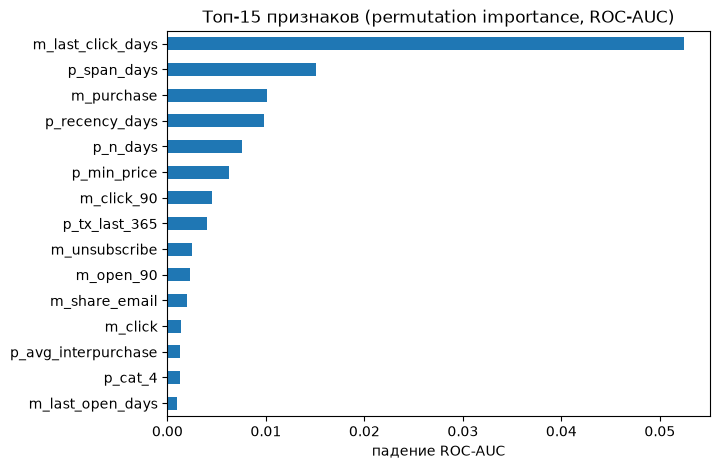

In [14]:
ax = imp.head(15)[::-1].plot(kind="barh", figsize=(7, 5),
                             title="Топ-15 признаков (permutation importance, ROC-AUC)")
ax.set_xlabel("падение ROC-AUC")

## 12. Проверка на утечку

Косвенные признаки отсутствия утечки:
- итоговый ROC-AUC ≈ 0.77 — высокий, но далёк от «подозрительной» единицы;
- в топе важности — поведенческие признаки давности (recency последнего клика, срок жизни
  клиента, давность покупки), а не что-то, однозначно раскрывающее будущее;
- все признаки посчитаны строго до точки среза, а события целевого окна в данных отсутствуют.

Дополнительно убеждаемся, что ни один одиночный признак не даёт «идеального» AUC.

In [15]:
from sklearn.metrics import roc_auc_score as _auc
single = {}
for c in X.columns:
    a = _auc(y_te, X_te[c])
    single[c] = max(a, 1 - a)      # признак может быть анти-коррелирован
pd.Series(single).sort_values(ascending=False).head(5).round(4)

m_click_90           0.6758
p_n_tx               0.6742
p_total_qty          0.6726
p_min_price          0.6713
m_last_click_days    0.6688
dtype: float64

## 13. Выводы

- Построена модель предсказания покупки в течение 90 дней; итоговый **ROC-AUC ≈ 0.77** на
  отложенной выборке.
- Наибольший вклад дают признаки **вовлечённости в рассылки** (давность последнего клика,
  клики за 90 дней) и **истории покупок** (срок жизни клиента, recency, средний чек).
- Категории обработаны устойчиво к смене вложенности — через присутствие id, а не позицию.
- Дисбаланс классов учтён взвешиванием и метрикой ROC-AUC; временна́я граница защищает от
  утечки будущего.

**Как использовать.** На проде: зафиксировать точку среза (текущая дата), пересчитать признаки
по истории до неё теми же функциями, применить обученную модель и ранжировать клиентов по
вероятности — верхние сегменты брать в приоритетные рассылки.

**Возможные улучшения:** признаки из агрегатов кампаний `full_campaign_daily_event*`
(средний open/click-rate кампаний, в которых участвовал клиент), сезонность покупок,
эмбеддинги категорий, калибровка вероятностей, отбор признаков.